# Классификация смартфонов по ценовой категории (Decision Tree + Random Forest)

**Датасет:** [Mobile Price Classification](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification) - 2000 смартфонов, 20 признаков, 4 ценовые категории
**Задача:** классификация ценовой категории (0 - бюджетный, 1 - средний, 2 - дорогой, 3 - премиум) по характеристикам смартфона

## 1. Краткая теория

**Дерево решений** рекурсивно разбивает пространство признаков по критерию Gini или энтропии. Каждый узел содержит условие вида $x_j \leq t$, каждый лист - метку класса. Интерпретируемая модель, но склонна к переобучению.

**Random Forest** - ансамбль деревьев с бэггингом: каждое дерево обучается на бутстрэп-выборке с случайным подмножеством признаков. Итоговое предсказание - голосование большинством:

$$\hat{y}(x) = \arg\max_k \sum_{b=1}^{B} \mathbb{I}[\hat{y}_b(x) = k]$$

Подробная теория - в [README.md](README.md).

## 2. Загрузка данных

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
import kagglehub

path = kagglehub.dataset_download('iabhishekofficial/mobile-price-classification')
df = pd.read_csv(f'{path}/train.csv')

In [2]:
print(f'Размер: {df.shape[0]} записей, {df.shape[1]} столбцов')
df.head()

Размер: 2000 записей, 21 столбцов


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

## 3. Первичный анализ

In [4]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


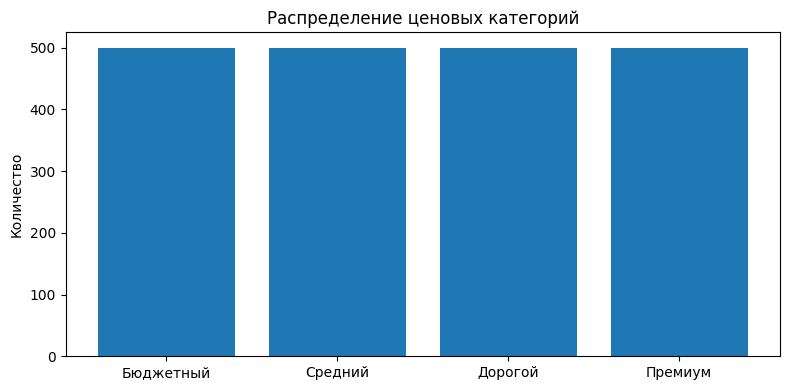

Классы сбалансированы: по 500 в каждом


In [5]:
# распределение целевой переменной
class_names = ['Бюджетный', 'Средний', 'Дорогой', 'Премиум']
counts = df['price_range'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(range(4), counts.values)
plt.xticks(range(4), class_names)
plt.ylabel('Количество')
plt.title('Распределение ценовых категорий')
plt.tight_layout()
plt.show()

print(f'Классы сбалансированы: по {counts.values[0]} в каждом')

Классы идеально сбалансированы (по 500 на категорию), accuracy адекватно отражает качество.

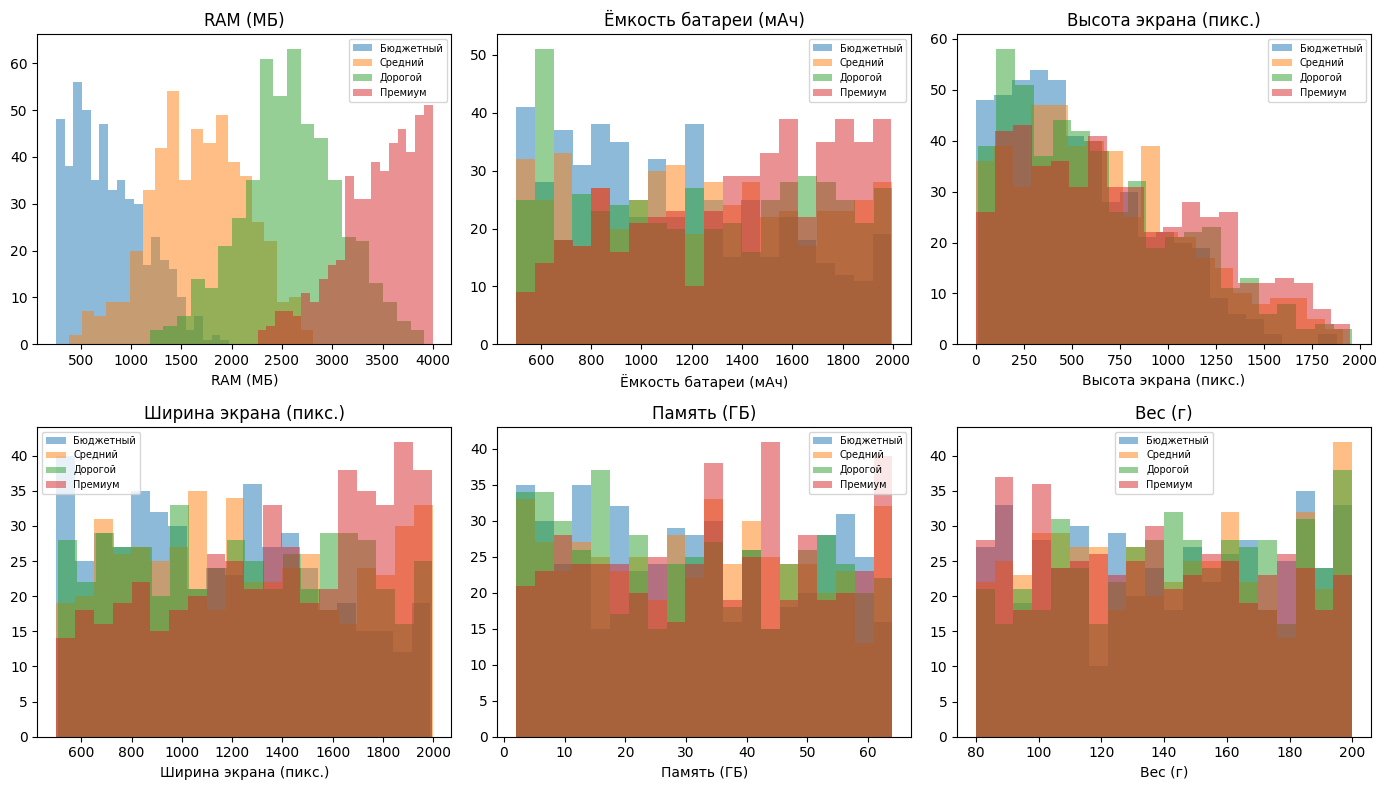

In [6]:
# распределение ключевых числовых признаков по категориям
key_features = ['ram', 'battery_power', 'px_height', 'px_width', 'int_memory', 'mobile_wt']
titles_ru = {'ram': 'RAM (МБ)', 'battery_power': 'Ёмкость батареи (мАч)',
             'px_height': 'Высота экрана (пикс.)', 'px_width': 'Ширина экрана (пикс.)',
             'int_memory': 'Память (ГБ)', 'mobile_wt': 'Вес (г)'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flat, key_features):
    for c in range(4):
        data = df[df['price_range'] == c][feat]
        ax.hist(data, bins=20, alpha=0.5, label=class_names[c])
    ax.set_title(titles_ru[feat])
    ax.set_xlabel(titles_ru[feat])
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

RAM - главный разделитель: распределения по категориям почти не пересекаются. Батарея, разрешение экрана и память тоже различаются между категориями, но с большим перекрытием.

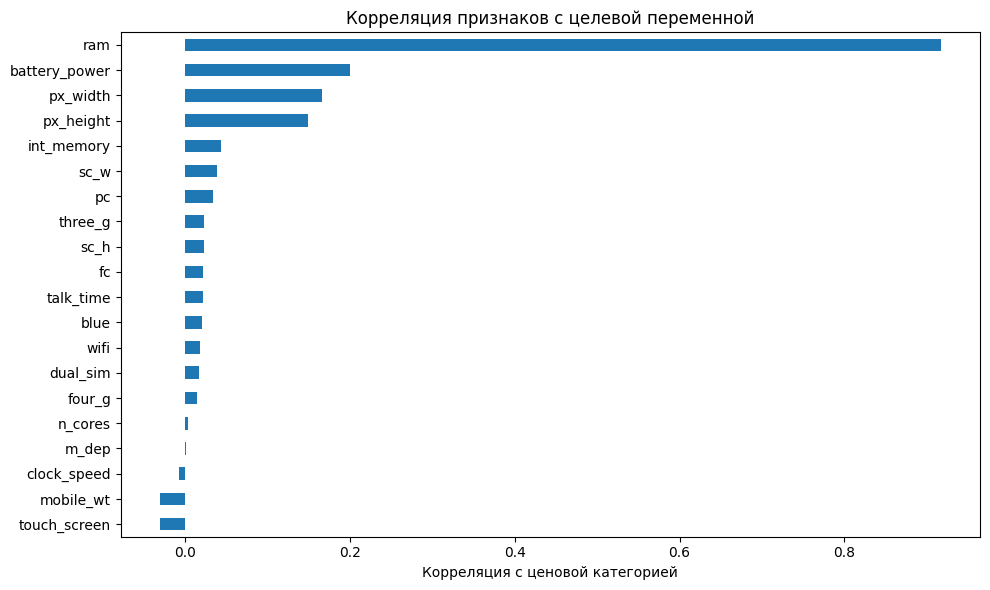

Топ-5 по корреляции:
  int_memory: 0.044
  px_height: 0.149
  px_width: 0.166
  battery_power: 0.201
  ram: 0.917


In [7]:
# корреляция признаков с целевой переменной
corr_with_target = df.corr()['price_range'].drop('price_range').sort_values()

plt.figure(figsize=(10, 6))
corr_with_target.plot(kind='barh')
plt.xlabel('Корреляция с ценовой категорией')
plt.title('Корреляция признаков с целевой переменной')
plt.tight_layout()
plt.show()

print(f'Топ-5 по корреляции:')
for feat, val in corr_with_target.tail(5).items():
    print(f'  {feat}: {val:.3f}')

RAM доминирует с корреляцией 0.917. Батарея (0.201) и разрешение экрана (px_width 0.166, px_height 0.149) значительно слабее. Большинство остальных признаков практически не коррелируют с ценовой категорией.

In [8]:
# пропуски
print(f'Пропуски: {df.isnull().sum().sum()}')

Пропуски: 0


## 4. Предобработка

In [9]:
# данные чистые, пропусков нет, все признаки числовые
# деревья не требуют масштабирования
X = df.drop(columns=['price_range'])
y = df['price_range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Распределение в train: {y_train.value_counts().sort_index().to_dict()}')
print(f'Распределение в test:  {y_test.value_counts().sort_index().to_dict()}')

X_train: (1600, 20), X_test: (400, 20)
Распределение в train: {0: 400, 1: 400, 2: 400, 3: 400}
Распределение в test:  {0: 100, 1: 100, 2: 100, 3: 100}


## 5. Обучение модели

### Дерево решений - baseline

In [10]:
# baseline: дерево без ограничений
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

train_acc = dt_baseline.score(X_train, y_train)
test_acc = dt_baseline.score(X_test, y_test)

print(f'Accuracy train: {train_acc:.4f}')
print(f'Accuracy test:  {test_acc:.4f}')
print(f'Глубина дерева: {dt_baseline.get_depth()}')
print(f'Листьев: {dt_baseline.get_n_leaves()}')

Accuracy train: 1.0000
Accuracy test:  0.8300
Глубина дерева: 11
Листьев: 158


Baseline дерево идеально запомнило train (1.0), но test accuracy=0.83 - переобучение. Глубина 11, 158 листьев - дерево слишком сложное для 1600 обучающих примеров.

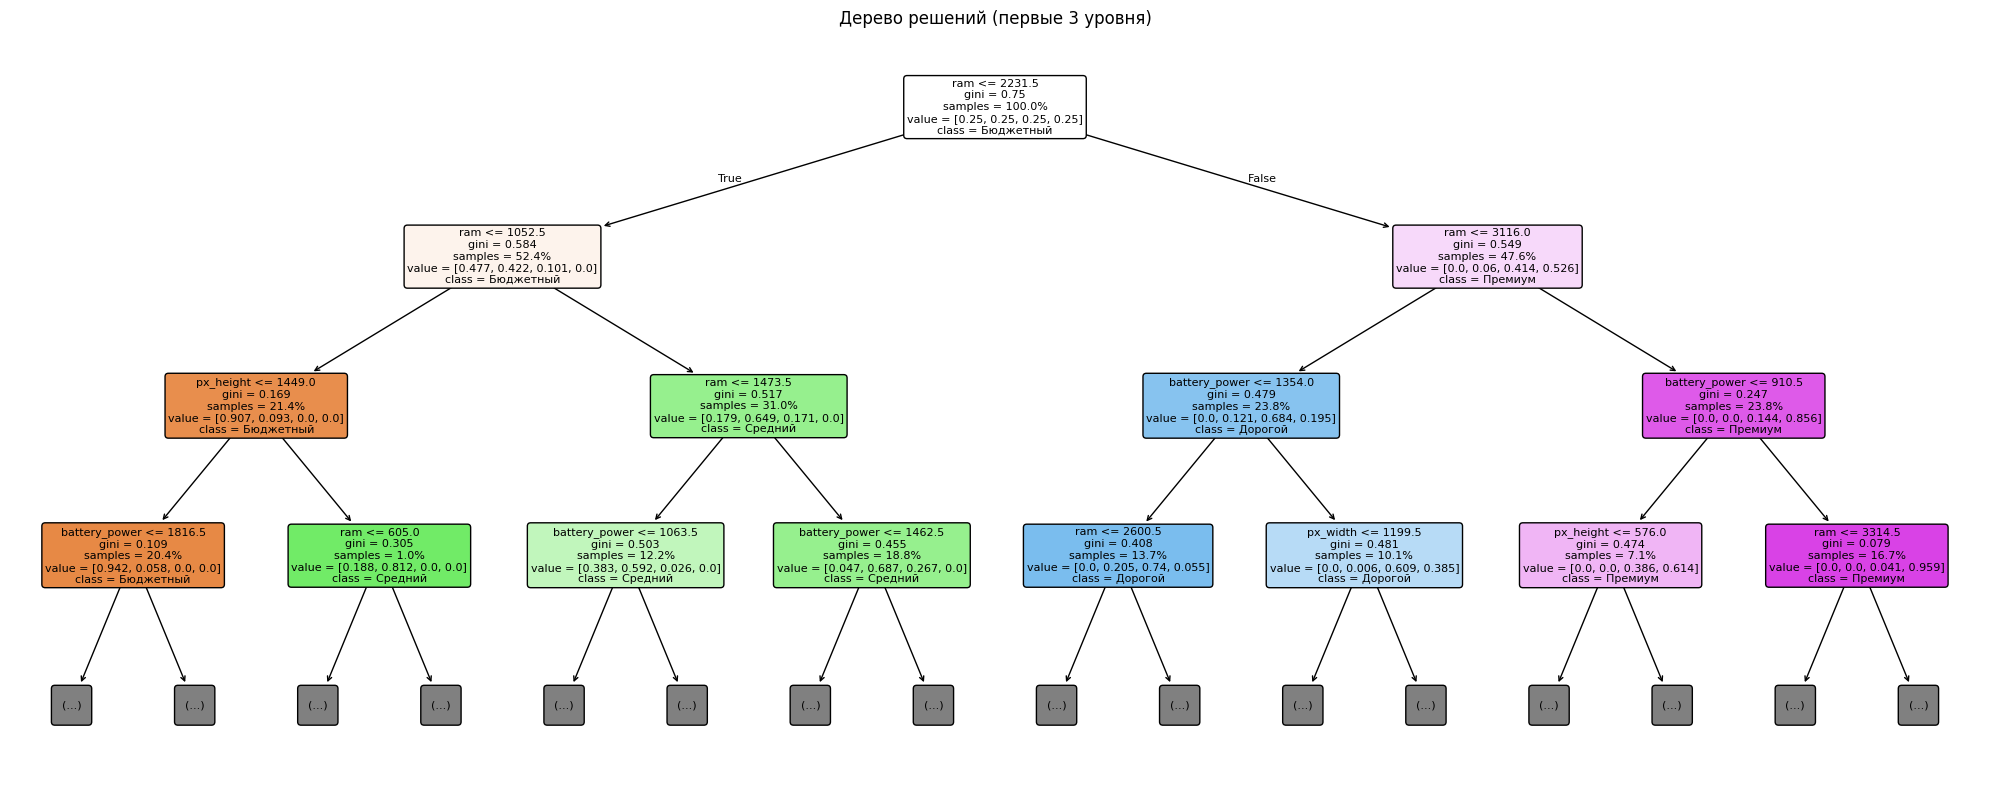

In [11]:
# визуализация baseline дерева (первые 3 уровня)
plt.figure(figsize=(20, 8))
plot_tree(dt_baseline, max_depth=3, feature_names=X.columns,
          class_names=class_names, filled=True, fontsize=8,
          proportion=True, rounded=True)
plt.title('Дерево решений (первые 3 уровня)')
plt.tight_layout()
plt.show()

Корень дерева разбивает по RAM - подтверждает анализ корреляций. Первые уровни используют RAM и разрешение экрана.

### Подбор глубины дерева

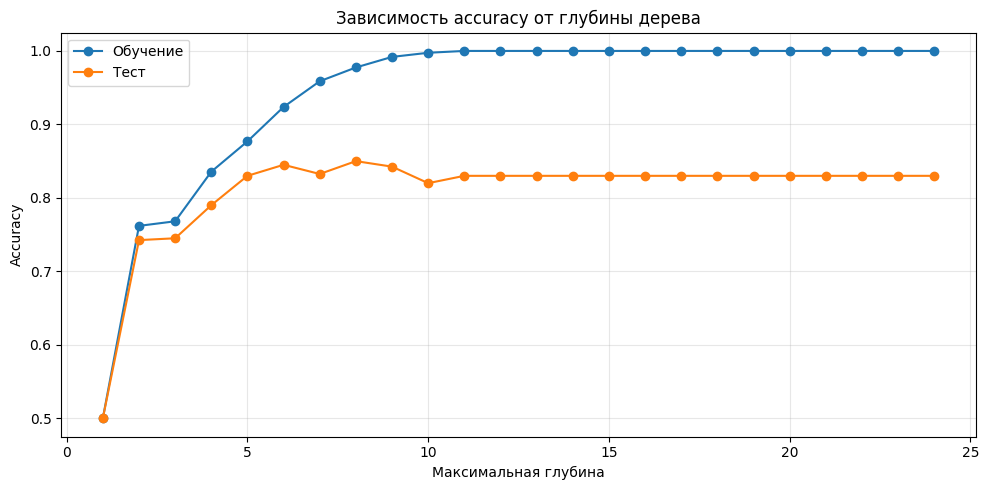

Лучшая глубина: 8, test accuracy: 0.8500


In [12]:
# подбор max_depth
depths = range(1, 25)
train_scores = []
test_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', label='Обучение')
plt.plot(depths, test_scores, 'o-', label='Тест')
plt.xlabel('Максимальная глубина')
plt.ylabel('Accuracy')
plt.title('Зависимость accuracy от глубины дерева')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(test_scores)]
print(f'Лучшая глубина: {best_depth}, test accuracy: {max(test_scores):.4f}')

Лучшая глубина по перебору - 8 (test accuracy=0.85). При глубине больше 10 train accuracy достигает 1.0, а test стагнирует на ~0.83 - переобучение.

In [13]:
# GridSearchCV для дерева
param_grid_dt = {
    'max_depth': [5, 7, 9, 11, 13],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(f'Лучшие параметры: {grid_dt.best_params_}')
print(f'CV accuracy: {grid_dt.best_score_:.4f}')
print(f'Test accuracy: {grid_dt.best_estimator_.score(X_test, y_test):.4f}')

Лучшие параметры: {'max_depth': 13, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV accuracy: 0.8300
Test accuracy: 0.8300


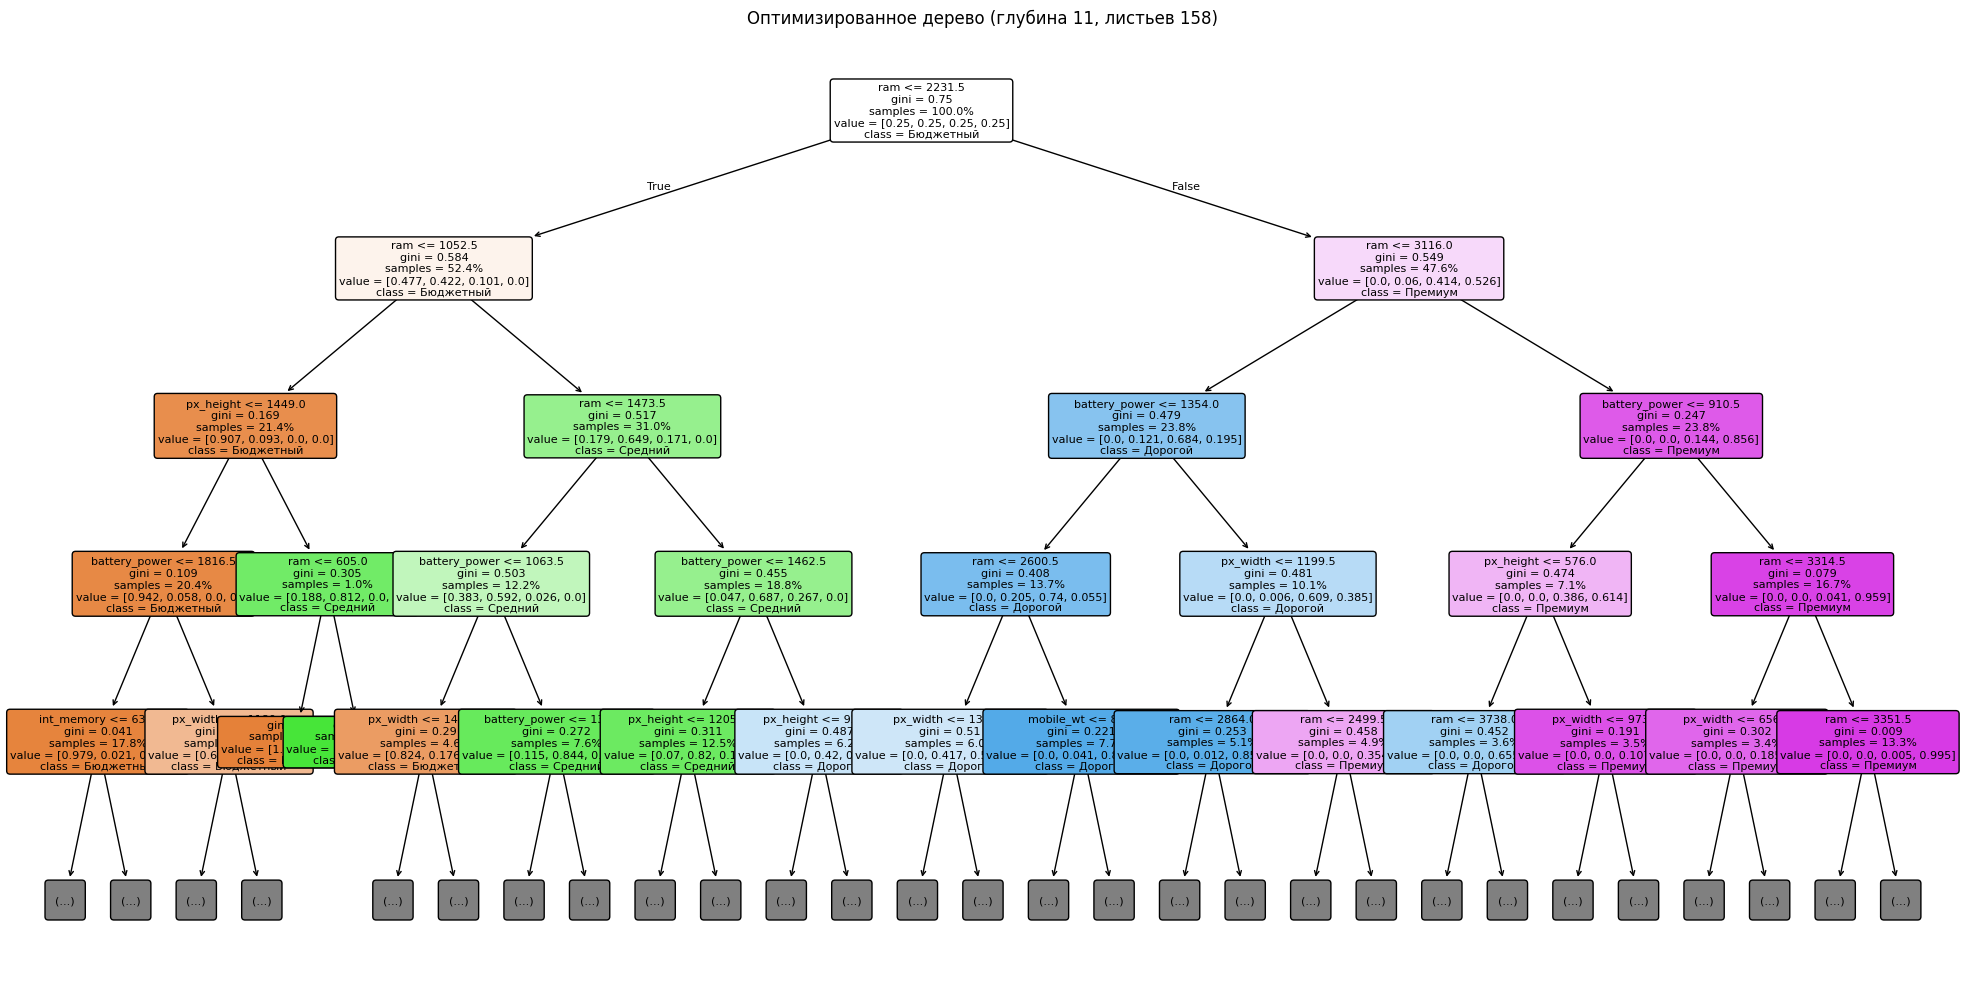

In [14]:
# финальное дерево
dt_best = grid_dt.best_estimator_

plt.figure(figsize=(20, 10))
plot_tree(dt_best, max_depth=4, feature_names=X.columns,
          class_names=class_names, filled=True, fontsize=8,
          proportion=True, rounded=True)
plt.title(f'Оптимизированное дерево (глубина {dt_best.get_depth()}, листьев {dt_best.get_n_leaves()})')
plt.tight_layout()
plt.show()

### Random Forest

In [15]:
# baseline RF
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

print(f'RF baseline - train accuracy: {rf_baseline.score(X_train, y_train):.4f}')
print(f'RF baseline - test accuracy:  {rf_baseline.score(X_test, y_test):.4f}')

RF baseline - train accuracy: 1.0000
RF baseline - test accuracy:  0.8800


In [16]:
# GridSearchCV для RF
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f'Лучшие параметры: {grid_rf.best_params_}')
print(f'CV accuracy: {grid_rf.best_score_:.4f}')
print(f'Test accuracy: {grid_rf.best_estimator_.score(X_test, y_test):.4f}')

Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
CV accuracy: 0.8719
Test accuracy: 0.8825


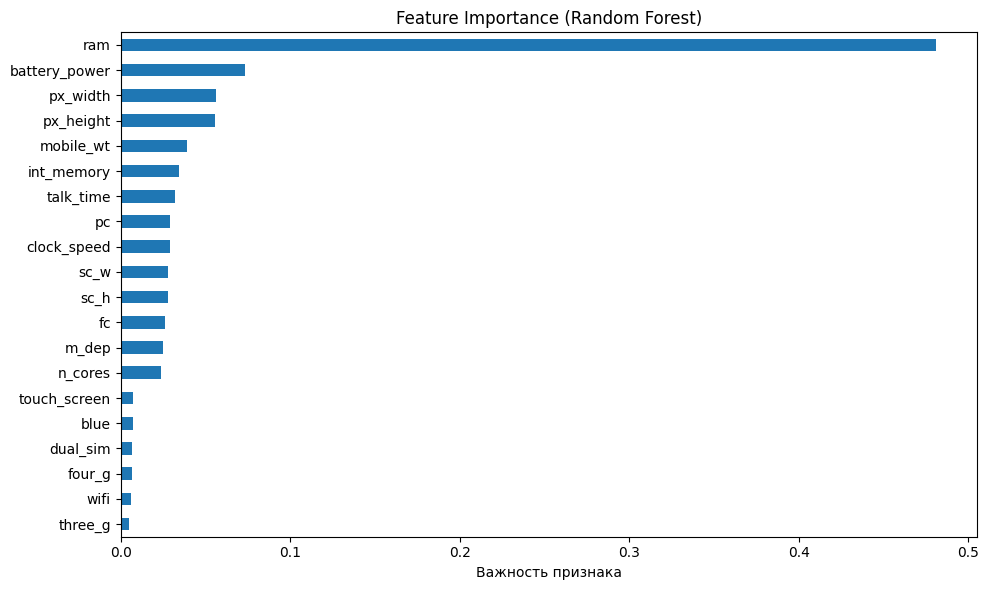

Топ-5 признаков:
  mobile_wt: 0.0388
  px_height: 0.0559
  px_width: 0.0562
  battery_power: 0.0731
  ram: 0.4810


In [17]:
rf_best = grid_rf.best_estimator_

# важность признаков
importances = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.xlabel('Важность признака')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print('Топ-5 признаков:')
for feat, val in importances.tail(5).items():
    print(f'  {feat}: {val:.4f}')

RAM доминирует в feature importance (0.48) с огромным отрывом. Батарея (0.073) и разрешение экрана (px_width 0.056, px_height 0.056) на втором-третьем месте.

## 6. Оценка качества

In [18]:
# сравнение моделей
models = {
    'Дерево (baseline)': dt_baseline,
    'Дерево (GridSearch)': dt_best,
    'RF (baseline)': rf_baseline,
    'RF (GridSearch)': rf_best
}

print(f'{"Модель":<25} {"Train":>8} {"Test":>8}')
print('-' * 43)
for name, m in models.items():
    tr = m.score(X_train, y_train)
    te = m.score(X_test, y_test)
    print(f'{name:<25} {tr:>8.4f} {te:>8.4f}')

Модель                       Train     Test
-------------------------------------------
Дерево (baseline)           1.0000   0.8300
Дерево (GridSearch)         1.0000   0.8300
RF (baseline)               1.0000   0.8800
RF (GridSearch)             1.0000   0.8825


In [19]:
# classification report для лучшей модели (RF)
y_pred_rf = rf_best.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=class_names))

              precision    recall  f1-score   support

   Бюджетный       0.95      0.96      0.96       100
     Средний       0.83      0.85      0.84       100
     Дорогой       0.83      0.78      0.80       100
     Премиум       0.92      0.94      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400


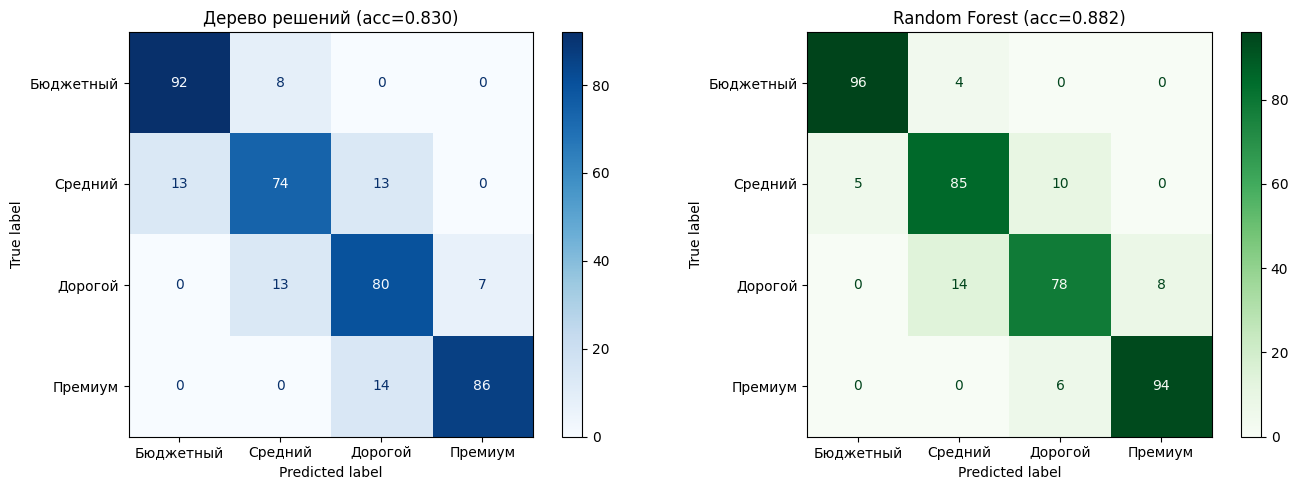

In [20]:
# confusion matrix: дерево vs RF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_pred_dt = dt_best.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=class_names).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Дерево решений (acc={dt_best.score(X_test, y_test):.3f})')

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'Random Forest (acc={rf_best.score(X_test, y_test):.3f})')

plt.tight_layout()
plt.show()

RF (accuracy=0.88) ошибается реже дерева (0.83). Основные ошибки обеих моделей - путаница Средний/Дорогой (F1=0.80-0.84 для RF, 0.76-0.77 для дерева). Бюджетный и Премиум классифицируются лучше всего (F1=0.96 и 0.93 у RF).

In [21]:
# classification report для дерева
print('Дерево решений:')
print(classification_report(y_test, y_pred_dt, target_names=class_names))

Дерево решений:
              precision    recall  f1-score   support

   Бюджетный       0.88      0.92      0.90       100
     Средний       0.78      0.74      0.76       100
     Дорогой       0.75      0.80      0.77       100
     Премиум       0.92      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



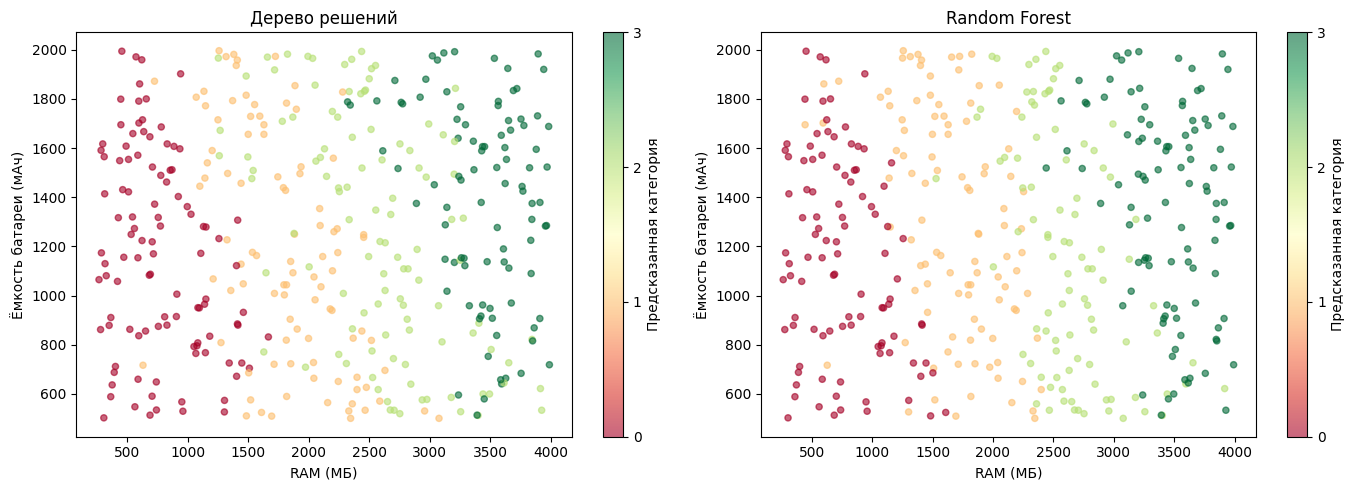

In [22]:
# визуализация разделения по двум главным признакам (RAM + battery)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, preds) in zip(axes, [('Дерево решений', y_pred_dt), ('Random Forest', y_pred_rf)]):
    scatter = ax.scatter(X_test['ram'], X_test['battery_power'],
                        c=preds, cmap='RdYlGn', alpha=0.6, s=20)
    ax.set_xlabel('RAM (МБ)')
    ax.set_ylabel('Ёмкость батареи (мАч)')
    ax.set_title(name)
    plt.colorbar(scatter, ax=ax, ticks=[0, 1, 2, 3],
                 label='Предсказанная категория')

plt.tight_layout()
plt.show()

На плоскости RAM-батарея видно чёткое разделение по RAM: модели корректно используют его как главный дискриминатор. RF даёт более гладкие границы по сравнению со ступенчатыми границами дерева.